# 09 · Robustez de la descomposición residencia–movilidad — Bogotá 2023

**Objetivo.** Determinar si la brecha de accesibilidad por sexo y los patrones por
estrato dependen de tres decisiones analíticas:

1. referencia poblacional completa o restringida a las categorías válidas de la dimensión;
2. destinos `core_50` o `extended_80`;
3. FPT condicionado a iniciar fuera del objetivo o no condicionado.

Para la referencia restringida, el kernel y la distribución residencial se estiman solo
con observaciones que pertenecen a las categorías analizadas. Los kernels de grupo se
contraen hacia ese kernel de referencia. La especificación completa reproduce la Gate 9.

La descomposición factorial y la asignación simétrica mujer–hombre mantienen cierre exacto.
Este notebook es una prueba de robustez, no una selección posterior de la especificación
que produzca el resultado más favorable.


In [3]:
%pip -q install pandas pyarrow numpy scipy matplotlib seaborn


In [4]:
from pathlib import Path
from datetime import datetime, timezone
import csv
import hashlib
import json
import os
import re
import shutil
import unicodedata
import zipfile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

ROOT = Path("/content/colombia-stochastic-access")
RAW = ROOT / "data/raw/bogota_em2023"
INTERIM = ROOT / "data/interim/bogota_em2023_gate10"
OUT = ROOT / "outputs/bogota_em2023/gate10"
DRIVE_BASE = Path("/content/drive/MyDrive/colombia-stochastic-access-data/bogota_em2023")
for directory in (RAW, INTERIM, OUT):
    directory.mkdir(parents=True, exist_ok=True)

SOURCE_URL = (
    "https://observatorio.movilidadbogota.gov.co/sites/default/files/"
    "2025-09/05_Base%20datos%20procesada%20EODH.zip"
)
PURPOSES = ("employment", "education", "health")
TARGET_DEFINITIONS = ("core_50", "extended_80")
CONDITIONING_MODES = ("outside_target", "all_residences")
REFERENCE_SCHEMES = ("full_population", "valid_dimension")
PRIMARY_TAU = 20.0
BOOTSTRAP_REPLICATES = 50
RANDOM_SEED = 202310

try:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
except Exception as exc:
    print(f"Entorno fuera de Colab o Drive no montado: {exc}")

gate4_dir = Path(os.environ.get("GATE4_DIR_OVERRIDE", DRIVE_BASE / "results/gate4"))
gate6_dir = Path(os.environ.get("GATE6_DIR_OVERRIDE", DRIVE_BASE / "results/gate6"))
gate9_dir = Path(os.environ.get("GATE9_DIR_OVERRIDE", DRIVE_BASE / "results/gate9"))
EDGE_PATH = gate4_dir / "transition_edges_utam.parquet"
TARGET_PATH = gate6_dir / "purpose_target_sets.csv"
GATE9_PATH = gate9_dir / "gate_9.json"
GATE9_POINT_PATH = gate9_dir / "residence_kernel_decomposition.csv"
GATE9_SEX_PATH = gate9_dir / "female_male_decomposition.csv"

required_paths = (EDGE_PATH, TARGET_PATH, GATE9_PATH, GATE9_POINT_PATH, GATE9_SEX_PATH)
missing = [str(path) for path in required_paths if not path.exists()]
if missing:
    raise FileNotFoundError("Faltan insumos validados: " + ", ".join(missing))

gate9 = json.loads(GATE9_PATH.read_text(encoding="utf-8"))
gate9_status = gate9.get("gate", gate9)
if not bool(gate9_status.get("gate_9_passed", False)):
    raise RuntimeError("La Compuerta 9 no fue aprobada.")

print("Kernel poblacional:", EDGE_PATH)
print("Resultados Gate 9:", gate9_dir)
print("Salida:", OUT)


Mounted at /content/drive
Kernel poblacional: /content/drive/MyDrive/colombia-stochastic-access-data/bogota_em2023/results/gate4/transition_edges_utam.parquet
Resultados Gate 9: /content/drive/MyDrive/colombia-stochastic-access-data/bogota_em2023/results/gate9
Salida: /content/colombia-stochastic-access/outputs/bogota_em2023/gate10


## 1. Recuperación de los microdatos

Se reutiliza el ZIP oficial almacenado en Drive. Las personas definen residencia mediante
`cod_utam_hg` y `fexp_per_5anos`; los viajes definen las transiciones mediante `fexp_vj`.


In [5]:
def sha256(path, chunk_size=1024 * 1024):
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        for chunk in iter(lambda: handle.read(chunk_size), b""):
            digest.update(chunk)
    return digest.hexdigest()


def valid_zip(path):
    path = Path(path)
    return path.exists() and path.stat().st_size > 0 and zipfile.is_zipfile(path)


def upload_archive(destination):
    from google.colab import files
    print("Descargue el ZIP oficial si no lo conserva:")
    print(SOURCE_URL)
    uploaded = files.upload()
    if len(uploaded) != 1:
        raise ValueError("Suba exactamente un archivo ZIP.")
    name, content = next(iter(uploaded.items()))
    temporary = destination.with_suffix(".zip.upload")
    temporary.write_bytes(content)
    del content
    if not valid_zip(temporary):
        temporary.unlink(missing_ok=True)
        raise ValueError(f"{name} no es un ZIP válido.")
    temporary.replace(destination)
    return "manual_upload"


archive = RAW / "processed_edoh.zip"
drive_archive = DRIVE_BASE / "processed_edoh.zip"
if valid_zip(archive):
    retrieval_method = "runtime_cache"
elif valid_zip(drive_archive):
    shutil.copy2(drive_archive, archive)
    retrieval_method = "google_drive_cache"
else:
    retrieval_method = upload_archive(archive)
    DRIVE_BASE.mkdir(parents=True, exist_ok=True)
    shutil.copy2(archive, drive_archive)


def safe_extract_recursive(zip_path, destination):
    destination.mkdir(parents=True, exist_ok=True)
    queue = [(Path(zip_path), destination)]
    visited = set()
    while queue:
        current, target = queue.pop(0)
        signature = (str(current.resolve()), str(target.resolve()))
        if signature in visited:
            continue
        visited.add(signature)
        root = target.resolve()
        with zipfile.ZipFile(current) as zipped:
            for member in zipped.infolist():
                resolved = (target / member.filename).resolve()
                if root != resolved and root not in resolved.parents:
                    raise ValueError(f"Ruta insegura en ZIP: {member.filename}")
            zipped.extractall(target)
        for nested in target.rglob("*.zip"):
            nested_target = nested.parent / nested.stem
            nested_signature = (str(nested.resolve()), str(nested_target.resolve()))
            if nested_signature not in visited:
                queue.append((nested, nested_target))


safe_extract_recursive(archive, INTERIM / "processed_edoh")
source_manifest = pd.DataFrame([{
    "source_id": "processed_edoh", "url": SOURCE_URL, "path": str(archive),
    "bytes": int(archive.stat().st_size), "sha256": sha256(archive),
    "retrieval_method": retrieval_method,
    "generated_utc": datetime.now(timezone.utc).isoformat(),
}])
source_manifest.to_csv(OUT / "source_manifest.csv", index=False)
display(source_manifest)


,source_id,url,path,bytes,sha256,retrieval_method,generated_utc
0,processed_edoh,https://observatorio.movilidadbogota.gov.co/si...,/content/colombia-stochastic-access/data/raw/b...,88826883,2509410f39713de4768872952e75e95809a99d7edf5b65...,google_drive_cache,2026-09-11T19:02:23.821773+00:00


In [6]:
def normalize(value):
    value = unicodedata.normalize("NFKD", str(value))
    value = "".join(char for char in value if not unicodedata.combining(char))
    return re.sub(r"[^a-z0-9]+", "_", value.lower().strip()).strip("_")


def clean_key(series):
    cleaned = series.astype("string").str.strip().str.replace(r"\.0$", "", regex=True)
    invalid = cleaned.map(normalize).isin(
        ["", "nan", "none", "na", "no_aplica", "sin_informacion"]
    )
    return cleaned.mask(invalid)


def canonical_utam(series):
    cleaned = clean_key(series)
    def canonical(value):
        if pd.isna(value):
            return pd.NA
        text = str(value).strip().upper().replace(" ", "")
        upr = re.fullmatch(r"UPR0*(\d+)", text)
        if upr:
            return f"UPR{int(upr.group(1)):04d}"
        utam = re.fullmatch(r"(?:UTAM)?0*(\d+)", text)
        if utam:
            return f"UTAM{int(utam.group(1)):03d}"
        return text
    return cleaned.map(canonical).astype("string")


def parse_number(series):
    raw = series.astype("string").str.strip()
    if float(raw.str.contains(",", regex=False, na=False).mean()) > 0.05:
        raw = raw.str.replace(".", "", regex=False).str.replace(",", ".", regex=False)
    return pd.to_numeric(raw, errors="coerce")


def csv_format(path):
    for encoding in ("utf-8-sig", "latin-1"):
        try:
            with path.open("r", encoding=encoding, errors="strict") as handle:
                sample = handle.read(32768)
            return encoding, csv.Sniffer().sniff(sample, delimiters=",;\t|").delimiter
        except (UnicodeDecodeError, csv.Error):
            continue
    raise ValueError(f"No fue posible detectar el formato: {path}")


def find_module(token, excluded=()):
    paths = list((INTERIM / "processed_edoh").rglob("*.csv"))
    candidates = [
        path for path in paths
        if token in normalize(path.stem)
        and not any(item in normalize(path.stem) for item in excluded)
    ]
    if not candidates:
        raise FileNotFoundError(f"No se encontró el módulo CSV: {token}")
    return sorted(candidates, key=lambda path: (len(path.parts), len(path.name)))[0]


def read_selected(path, required):
    encoding, delimiter = csv_format(path)
    header = pd.read_csv(path, sep=delimiter, encoding=encoding, nrows=0)
    mapping = {normalize(column): column for column in header.columns}
    absent = sorted(set(required) - set(mapping))
    if absent:
        raise KeyError(f"Faltan columnas en {path.name}: {absent}")
    frame = pd.read_csv(
        path, sep=delimiter, encoding=encoding,
        usecols=[mapping[column] for column in required], dtype="string", low_memory=False,
    )
    frame.columns = [normalize(column) for column in frame.columns]
    return frame


trips = read_selected(
    find_module("viaje", excluded=("etapa",)),
    ["key_hg", "utam_ori", "utam_des", "fexp_vj", "sexo", "estra_hg"],
)
persons = read_selected(
    find_module("persona"),
    ["key_hg", "cod_utam_hg", "fexp_per_5anos", "sexo", "estra_hg"],
)

trips["household"] = clean_key(trips["key_hg"])
trips["utam_ori"] = canonical_utam(trips["utam_ori"])
trips["utam_des"] = canonical_utam(trips["utam_des"])
trips["weight"] = parse_number(trips["fexp_vj"])
trips["sex_group"] = trips["sexo"].map(normalize)
trips["stratum_group"] = clean_key(trips["estra_hg"])
trips = trips[
    trips[["household", "utam_ori", "utam_des"]].notna().all(axis=1)
    & trips["weight"].gt(0)
].reset_index(drop=True)

persons["household"] = clean_key(persons["key_hg"])
persons["residence_utam"] = canonical_utam(persons["cod_utam_hg"])
persons["weight"] = parse_number(persons["fexp_per_5anos"])
persons["sex_group"] = persons["sexo"].map(normalize)
persons["stratum_group"] = clean_key(persons["estra_hg"])
persons = persons[
    persons[["household", "residence_utam"]].notna().all(axis=1)
    & persons["weight"].gt(0)
].reset_index(drop=True)

print("Viajes válidos:", f"{len(trips):,}")
print("Personas válidas:", f"{len(persons):,}")


Viajes válidos: 97,796
Personas válidas: 64,989


## 2. Auditoría de categorías y soporte

La cobertura válida se calcula antes de construir las referencias restringidas. No se
reclasifican valores faltantes, cero ni categorías no estándar. Se conservan en la
auditoría para cuantificar su influencia potencial.


In [7]:
VALID_LEVELS = {
    "sex": ("mujer", "hombre"),
    "stratum": tuple(map(str, range(1, 7))),
}


def validity_mask(frame, dimension):
    column = "sex_group" if dimension == "sex" else "stratum_group"
    return frame[column].isin(VALID_LEVELS[dimension]).fillna(False).to_numpy(dtype=bool)


audit_rows = []
for module, frame in (("persons", persons), ("trips", trips)):
    for dimension in VALID_LEVELS:
        mask = validity_mask(frame, dimension)
        audit_rows.append({
            "module": module, "dimension": dimension,
            "rows": int(len(frame)), "valid_rows": int(mask.sum()),
            "row_valid_share": float(mask.mean()),
            "total_weight": float(frame["weight"].sum()),
            "valid_weight": float(frame.loc[mask, "weight"].sum()),
            "weighted_valid_share": float(frame.loc[mask, "weight"].sum() / frame["weight"].sum()),
        })
category_coverage = pd.DataFrame(audit_rows)
category_coverage.to_csv(OUT / "category_coverage_audit.csv", index=False)

excluded_rows = []
for module, frame in (("persons", persons), ("trips", trips)):
    for dimension in VALID_LEVELS:
        column = "sex_group" if dimension == "sex" else "stratum_group"
        valid = validity_mask(frame, dimension)
        excluded = frame.loc[~valid].copy()
        labels = excluded[column].fillna("<missing>")
        summary = excluded.assign(label=labels).groupby("label", dropna=False).agg(
            rows=("weight", "size"), weighted_count=("weight", "sum")
        ).reset_index()
        for row in summary.itertuples(index=False):
            excluded_rows.append({
                "module": module, "dimension": dimension, "label": str(row.label),
                "rows": int(row.rows), "weighted_count": float(row.weighted_count),
            })
excluded_categories = pd.DataFrame(excluded_rows)
excluded_categories.to_csv(OUT / "excluded_category_audit.csv", index=False)
display(category_coverage)
display(excluded_categories)


,module,dimension,rows,valid_rows,row_valid_share,total_weight,valid_weight,weighted_valid_share
0,persons,sex,64989,64975,0.999785,9273186.5,9270389.5,0.999698
1,persons,stratum,64989,48989,0.753804,9273186.5,7451684.8,0.803573
2,trips,sex,97796,97779,0.999826,16440081.3,16435537.0,0.999724
3,trips,stratum,97796,77300,0.790421,16440081.3,13816305.2,0.840404


,module,dimension,label,rows,weighted_count
0,persons,sex,intersexual,14,2797.0
1,persons,stratum,<missing>,16000,1821501.7
2,trips,sex,intersexual,17,4544.3
3,trips,stratum,<missing>,20496,2623776.1


In [8]:
edges = pd.read_parquet(EDGE_PATH).copy()
for column in ("utam_ori", "utam_des"):
    edges[column] = canonical_utam(edges[column])
edges = edges.dropna(subset=["utam_ori", "utam_des"])
nodes = sorted(set(edges["utam_ori"]) | set(edges["utam_des"]))
node_to_index = {node: index for index, node in enumerate(nodes)}
n_nodes = len(nodes)

P0 = np.zeros((n_nodes, n_nodes), dtype=float)
for row in edges.itertuples(index=False):
    P0[node_to_index[row.utam_ori], node_to_index[row.utam_des]] = float(
        row.transition_probability
    )
if not np.allclose(P0.sum(axis=1), 1.0, atol=1e-10):
    raise RuntimeError("El kernel poblacional no es estocástico.")

trip_support = trips["utam_ori"].isin(node_to_index) & trips["utam_des"].isin(node_to_index)
person_support = persons["residence_utam"].isin(node_to_index)
support_audit = pd.DataFrame([{
    "trip_weight_support_share": float(
        trips.loc[trip_support, "weight"].sum() / trips["weight"].sum()
    ),
    "person_weight_residential_support_share": float(
        persons.loc[person_support, "weight"].sum() / persons["weight"].sum()
    ),
}])
support_audit.to_csv(OUT / "robustness_support_audit.csv", index=False)
trips = trips.loc[trip_support].reset_index(drop=True)
persons = persons.loc[person_support].reset_index(drop=True)

origin_index = trips["utam_ori"].map(node_to_index).to_numpy(dtype=int)
destination_index = trips["utam_des"].map(node_to_index).to_numpy(dtype=int)
base_trip_weight = trips["weight"].to_numpy(dtype=float)
residence_index = persons["residence_utam"].map(node_to_index).to_numpy(dtype=int)
base_person_weight = persons["weight"].to_numpy(dtype=float)

target_table = pd.read_csv(TARGET_PATH, dtype={"utam": "string"})
target_table["utam"] = target_table["utam"].astype("string").str.strip().str.upper()
target_sets = {}
for purpose in PURPOSES:
    for definition in TARGET_DEFINITIONS:
        codes = set(target_table.loc[
            target_table["purpose_group"].eq(purpose)
            & target_table["target_definition"].eq(definition), "utam"
        ])
        missing_codes = sorted(codes - set(nodes))
        if not codes or missing_codes:
            raise RuntimeError(
                f"Objetivo inválido {purpose}/{definition}; fuera del kernel: {missing_codes}"
            )
        target_sets[(purpose, definition)] = np.array(
            sorted(node_to_index[code] for code in codes), dtype=int
        )

expected_groups = {
    "sex:mujer": ("sex", "mujer"),
    "sex:hombre": ("sex", "hombre"),
}
for level in map(str, range(1, 7)):
    expected_groups[f"stratum:{level}"] = ("stratum", level)


def group_mask(frame, dimension, level):
    column = "sex_group" if dimension == "sex" else "stratum_group"
    return frame[column].eq(level).fillna(False).to_numpy(dtype=bool)


trip_masks = {gid: group_mask(trips, dim, level) for gid, (dim, level) in expected_groups.items()}
person_masks = {gid: group_mask(persons, dim, level) for gid, (dim, level) in expected_groups.items()}
reference_trip_masks = {dim: validity_mask(trips, dim) for dim in VALID_LEVELS}
reference_person_masks = {dim: validity_mask(persons, dim) for dim in VALID_LEVELS}

print("Nodos:", n_nodes)
print("Objetivos:", {f"{p}/{d}": len(t) for (p, d), t in target_sets.items()})
display(support_audit)


Nodos: 141
Objetivos: {'employment/core_50': 30, 'employment/extended_80': 69, 'education/core_50': 29, 'education/extended_80': 66, 'health/core_50': 19, 'health/extended_80': 50}


,trip_weight_support_share,person_weight_residential_support_share
0,1.0,0.998209


## 3. Especificaciones de robustez

`outside_target` reproduce la convención anterior y renormaliza la residencia fuera de
los nodos objetivo. `all_residences` conserva toda la masa; residir en un nodo objetivo
implica FPT cero. La segunda opción evalúa si el condicionamiento ocultaba una ventaja
residencial local.


In [9]:
def regularized_kernel(mask, tau, pool, row_multiplier=None):
    selected = np.flatnonzero(mask)
    original = base_trip_weight[selected]
    multiplicity = (
        np.ones(len(selected), dtype=float)
        if row_multiplier is None else row_multiplier[selected].astype(float)
    )
    weights = original * multiplicity
    squared = original**2 * multiplicity
    origins = origin_index[selected]
    destinations = destination_index[selected]
    positive = weights > 0
    weights, squared = weights[positive], squared[positive]
    origins, destinations = origins[positive], destinations[positive]
    W = np.zeros((n_nodes, n_nodes), dtype=float)
    np.add.at(W, (origins, destinations), weights)
    out = W.sum(axis=1)
    sum_sq = np.bincount(origins, weights=squared, minlength=n_nodes)
    ess = np.divide(out**2, sum_sq, out=np.zeros(n_nodes), where=sum_sq > 0)
    empirical = np.zeros_like(W)
    observed = out > 0
    empirical[observed] = W[observed] / out[observed, None]
    omega = ess / (ess + float(tau))
    return omega[:, None] * empirical + (1.0 - omega[:, None]) * pool


def residential_distribution(mask=None, row_multiplier=None):
    if mask is None:
        mask = np.ones(len(persons), dtype=bool)
    selected = np.flatnonzero(mask)
    multiplicity = (
        np.ones(len(selected), dtype=float)
        if row_multiplier is None else row_multiplier[selected].astype(float)
    )
    weights = base_person_weight[selected] * multiplicity
    mu = np.bincount(residence_index[selected], weights=weights, minlength=n_nodes).astype(float)
    if not np.isfinite(mu).all() or mu.sum() <= 0:
        raise RuntimeError("Distribución residencial vacía o no finita.")
    return mu / mu.sum()


def first_passage_by_origin(P, targets):
    target_mask = np.zeros(n_nodes, dtype=bool)
    target_mask[targets] = True
    transient = np.flatnonzero(~target_mask)
    Q = P[np.ix_(transient, transient)]
    mean = np.linalg.solve(np.eye(len(transient)) - Q, np.ones(len(transient)))
    full = np.zeros(n_nodes, dtype=float)
    full[transient] = mean
    return full


def mean_fpt(h, mu, targets, conditioning):
    if conditioning == "all_residences":
        return float(mu @ h)
    eligible = np.ones(n_nodes, dtype=bool)
    eligible[targets] = False
    mass = float(mu[eligible].sum())
    if mass <= 0:
        raise RuntimeError("No hay masa residencial fuera del objetivo.")
    return float((mu[eligible] / mass) @ h[eligible])


def factorial_values(href, hg, muref, mug, targets, conditioning):
    B = mean_fpt(href, muref, targets, conditioning)
    C = mean_fpt(href, mug, targets, conditioning)
    K = mean_fpt(hg, muref, targets, conditioning)
    G = mean_fpt(hg, mug, targets, conditioning)
    residential = C - B
    kernel = K - B
    interaction = G - C - K + B
    total = G - B
    return {
        "reference_baseline": B, "residence_only": C,
        "kernel_only": K, "group_observed": G,
        "residential_main": residential, "kernel_main": kernel,
        "interaction": interaction,
        "shapley_residential": residential + 0.5 * interaction,
        "shapley_kernel": kernel + 0.5 * interaction,
        "total_gap": total,
        "closure_error": total - residential - kernel - interaction,
    }


def sex_gap_values(h_w, h_m, mu_w, mu_m, targets, conditioning):
    mm = mean_fpt(h_m, mu_m, targets, conditioning)
    mw = mean_fpt(h_m, mu_w, targets, conditioning)
    wm = mean_fpt(h_w, mu_m, targets, conditioning)
    ww = mean_fpt(h_w, mu_w, targets, conditioning)
    residential = 0.5 * ((mw - mm) + (ww - wm))
    kernel = 0.5 * ((wm - mm) + (ww - mw))
    total = ww - mm
    return {
        "male_total_fpt": mm, "female_total_fpt": ww,
        "female_minus_male_total": total,
        "residential_contribution": residential,
        "kernel_contribution": kernel,
        "closure_error": total - residential - kernel,
    }


mu_full = residential_distribution()
mu_valid = {
    dimension: residential_distribution(reference_person_masks[dimension])
    for dimension in VALID_LEVELS
}
group_mu = {gid: residential_distribution(person_masks[gid]) for gid in expected_groups}
reference_kernels = {
    "full_population": {dimension: P0 for dimension in VALID_LEVELS},
    "valid_dimension": {
        dimension: regularized_kernel(reference_trip_masks[dimension], PRIMARY_TAU, P0)
        for dimension in VALID_LEVELS
    },
}
reference_mu = {
    "full_population": {dimension: mu_full for dimension in VALID_LEVELS},
    "valid_dimension": mu_valid,
}
group_kernels = {}
for scheme in REFERENCE_SCHEMES:
    group_kernels[scheme] = {
        gid: regularized_kernel(
            trip_masks[gid], PRIMARY_TAU, reference_kernels[scheme][dimension]
        )
        for gid, (dimension, _) in expected_groups.items()
    }

point_rows = []
sex_rows = []
for scheme in REFERENCE_SCHEMES:
    for purpose in PURPOSES:
        for definition in TARGET_DEFINITIONS:
            targets = target_sets[(purpose, definition)]
            reference_h = {
                dimension: first_passage_by_origin(
                    reference_kernels[scheme][dimension], targets
                ) for dimension in VALID_LEVELS
            }
            group_h = {
                gid: first_passage_by_origin(group_kernels[scheme][gid], targets)
                for gid in expected_groups
            }
            for conditioning in CONDITIONING_MODES:
                for gid, (dimension, level) in expected_groups.items():
                    values = factorial_values(
                        reference_h[dimension], group_h[gid],
                        reference_mu[scheme][dimension], group_mu[gid],
                        targets, conditioning,
                    )
                    point_rows.append({
                        "reference_scheme": scheme, "target_definition": definition,
                        "conditioning": conditioning, "purpose_group": purpose,
                        "group_id": gid, "dimension": dimension, "level": level,
                        **values,
                    })
                values = sex_gap_values(
                    group_h["sex:mujer"], group_h["sex:hombre"],
                    group_mu["sex:mujer"], group_mu["sex:hombre"],
                    targets, conditioning,
                )
                sex_rows.append({
                    "reference_scheme": scheme, "target_definition": definition,
                    "conditioning": conditioning, "purpose_group": purpose, **values,
                })

point = pd.DataFrame(point_rows)
sex_robustness = pd.DataFrame(sex_rows)
point.to_csv(OUT / "robustness_factorial_point_estimates.csv", index=False)
sex_robustness.to_csv(OUT / "robustness_female_male_point_estimates.csv", index=False)
display(sex_robustness)


,reference_scheme,target_definition,conditioning,purpose_group,male_total_fpt,female_total_fpt,female_minus_male_total,residential_contribution,kernel_contribution,closure_error
0,full_population,core_50,outside_target,employment,4.111272,5.110021,0.998749,-0.032536,1.031285,0.0
1,full_population,core_50,all_residences,employment,3.186408,3.940621,0.754213,-0.043091,0.797304,0.0
2,full_population,extended_80,outside_target,employment,2.046756,2.405173,0.358417,-0.019534,0.377951,0.0
3,full_population,extended_80,all_residences,employment,0.802121,0.928769,0.126648,-0.020400,0.147048,0.0
4,full_population,core_50,outside_target,education,4.305536,5.132898,0.827362,-0.012526,0.839888,0.0
5,full_population,core_50,all_residences,education,2.865737,3.457973,0.592236,0.029853,0.562383,0.0
6,full_population,extended_80,outside_target,education,2.061387,2.300176,0.238789,-0.012263,0.251052,0.0
7,full_population,extended_80,all_residences,education,0.624954,0.715167,0.090213,0.013141,0.077071,0.0
8,full_population,core_50,outside_target,health,6.257356,6.962721,0.705366,-0.030744,0.736110,0.0
9,full_population,core_50,all_residences,health,5.247627,5.817789,0.570162,-0.046048,0.616209,0.0


## 4. Reproducción de la especificación principal

Antes de interpretar sensibilidades, se exige que `full_population + core_50 +
outside_target` reproduzca numéricamente la Gate 9.


In [10]:
gate9_point = pd.read_csv(GATE9_POINT_PATH, dtype={"level": "string"})
gate9_sex = pd.read_csv(GATE9_SEX_PATH)
primary_point = point[
    point["reference_scheme"].eq("full_population")
    & point["target_definition"].eq("core_50")
    & point["conditioning"].eq("outside_target")
].copy()
comparison = primary_point.merge(
    gate9_point,
    on=["group_id", "dimension", "level", "purpose_group"],
    suffixes=("_gate10", "_gate9"),
)
point_columns = [
    "group_observed", "residential_main", "kernel_main", "interaction", "total_gap"
]
point_replication_error = max(
    float((comparison[f"{column}_gate10"] - comparison[f"{column}_gate9"]).abs().max())
    for column in point_columns
)

primary_sex = sex_robustness[
    sex_robustness["reference_scheme"].eq("full_population")
    & sex_robustness["target_definition"].eq("core_50")
    & sex_robustness["conditioning"].eq("outside_target")
]
sex_comparison = primary_sex.merge(gate9_sex, on="purpose_group", suffixes=("_gate10", "_gate9"))
sex_columns = [
    "female_minus_male_total", "residential_contribution", "kernel_contribution"
]
sex_replication_error = max(
    float((sex_comparison[f"{column}_gate10"] - sex_comparison[f"{column}_gate9"]).abs().max())
    for column in sex_columns
)
replication_audit = pd.DataFrame([{
    "maximum_group_decomposition_error": point_replication_error,
    "maximum_sex_decomposition_error": sex_replication_error,
}])
replication_audit.to_csv(OUT / "gate9_replication_audit.csv", index=False)
display(replication_audit)


,maximum_group_decomposition_error,maximum_sex_decomposition_error
0,8.881784e-16,1.110223e-16


## 5. Bootstrap de robustez para la brecha por sexo

Una multiplicidad Poisson(1) común se aplica a personas y viajes del hogar. En la
referencia válida, el kernel de referencia también se reestima en cada réplica. Se
evalúan todas las combinaciones de referencia, objetivo y condicionamiento.


In [11]:
all_households = pd.Index(sorted(
    set(trips["household"].dropna().astype(str))
    | set(persons["household"].dropna().astype(str))
))
household_to_code = {household: index for index, household in enumerate(all_households)}
trip_household_codes = trips["household"].astype(str).map(household_to_code).to_numpy(dtype=int)
person_household_codes = persons["household"].astype(str).map(household_to_code).to_numpy(dtype=int)

rng = np.random.default_rng(RANDOM_SEED)
bootstrap_rows = []
for replicate in range(1, BOOTSTRAP_REPLICATES + 1):
    multiplicity = rng.poisson(1, len(all_households))
    trip_multiplier = multiplicity[trip_household_codes]
    person_multiplier = multiplicity[person_household_codes]
    mu_w = residential_distribution(person_masks["sex:mujer"], person_multiplier)
    mu_m = residential_distribution(person_masks["sex:hombre"], person_multiplier)

    reference_kernel_boot = {
        "full_population": P0,
        "valid_dimension": regularized_kernel(
            reference_trip_masks["sex"], PRIMARY_TAU, P0, trip_multiplier
        ),
    }
    for scheme in REFERENCE_SCHEMES:
        pool = reference_kernel_boot[scheme]
        P_w = regularized_kernel(trip_masks["sex:mujer"], PRIMARY_TAU, pool, trip_multiplier)
        P_m = regularized_kernel(trip_masks["sex:hombre"], PRIMARY_TAU, pool, trip_multiplier)
        for purpose in PURPOSES:
            for definition in TARGET_DEFINITIONS:
                targets = target_sets[(purpose, definition)]
                h_w = first_passage_by_origin(P_w, targets)
                h_m = first_passage_by_origin(P_m, targets)
                for conditioning in CONDITIONING_MODES:
                    values = sex_gap_values(h_w, h_m, mu_w, mu_m, targets, conditioning)
                    bootstrap_rows.append({
                        "replicate": int(replicate), "reference_scheme": scheme,
                        "target_definition": definition, "conditioning": conditioning,
                        "purpose_group": purpose, **values,
                    })
    if replicate % 10 == 0:
        print(f"Bootstrap {replicate}/{BOOTSTRAP_REPLICATES}")

bootstrap = pd.DataFrame(bootstrap_rows)
bootstrap.to_parquet(OUT / "robustness_sex_household_bootstrap.parquet", index=False)

effects = [
    "female_minus_male_total", "residential_contribution", "kernel_contribution"
]
interval_rows = []
keys = ["reference_scheme", "target_definition", "conditioning", "purpose_group"]
point_index = sex_robustness.set_index(keys)
for group_key, frame in bootstrap.groupby(keys, observed=True):
    for effect in effects:
        values = frame[effect]
        interval_rows.append({
            **dict(zip(keys, group_key)), "effect": effect,
            "point_estimate": float(point_index.loc[group_key, effect]),
            "bootstrap_mean": float(values.mean()),
            "bootstrap_sd": float(values.std()),
            "ci_lower": float(values.quantile(0.025)),
            "ci_upper": float(values.quantile(0.975)),
        })
intervals = pd.DataFrame(interval_rows)
intervals.to_csv(OUT / "robustness_sex_bootstrap_intervals.csv", index=False)

stability = sex_robustness.groupby("purpose_group", observed=True).agg(
    minimum_total_gap=("female_minus_male_total", "min"),
    maximum_total_gap=("female_minus_male_total", "max"),
    minimum_residential_contribution=("residential_contribution", "min"),
    maximum_residential_contribution=("residential_contribution", "max"),
    minimum_kernel_contribution=("kernel_contribution", "min"),
    maximum_kernel_contribution=("kernel_contribution", "max"),
).reset_index()
stability.to_csv(OUT / "robustness_sex_stability_summary.csv", index=False)
display(stability)
display(intervals)


Bootstrap 10/50
Bootstrap 20/50
Bootstrap 30/50
Bootstrap 40/50
Bootstrap 50/50


,purpose_group,minimum_total_gap,maximum_total_gap,minimum_residential_contribution,maximum_residential_contribution,minimum_kernel_contribution,maximum_kernel_contribution
0,education,0.090213,0.827420,-0.012526,0.029856,0.077071,0.839945
1,employment,0.126648,0.998784,-0.043093,-0.019534,0.147047,1.031322
2,health,0.493413,0.958984,-0.046048,-0.030744,0.532447,0.996932


,reference_scheme,target_definition,conditioning,purpose_group,effect,point_estimate,bootstrap_mean,bootstrap_sd,ci_lower,ci_upper
0,full_population,core_50,all_residences,education,female_minus_male_total,0.592236,0.623801,0.110450,0.423473,0.864366
1,full_population,core_50,all_residences,education,residential_contribution,0.029853,0.030443,0.030089,-0.031184,0.078076
2,full_population,core_50,all_residences,education,kernel_contribution,0.562383,0.593358,0.099973,0.429565,0.794747
3,full_population,core_50,all_residences,employment,female_minus_male_total,0.754213,0.771870,0.132191,0.532483,1.022498
4,full_population,core_50,all_residences,employment,residential_contribution,-0.043091,-0.047351,0.028843,-0.091990,0.011728
...,...,...,...,...,...,...,...,...,...,...
67,valid_dimension,extended_80,outside_target,employment,residential_contribution,-0.019534,-0.019727,0.008548,-0.031913,-0.002059
68,valid_dimension,extended_80,outside_target,employment,kernel_contribution,0.377949,0.379302,0.048326,0.299687,0.481928
69,valid_dimension,extended_80,outside_target,health,female_minus_male_total,0.958984,0.982463,0.216073,0.633339,1.440000
70,valid_dimension,extended_80,outside_target,health,residential_contribution,-0.037948,-0.045945,0.033578,-0.108166,0.022025


## 6. Visualización de estabilidad

Cada punto representa una de las ocho combinaciones analíticas. La separación entre el
componente residencial y el kernel permite verificar si la conclusión depende de una
única convención.


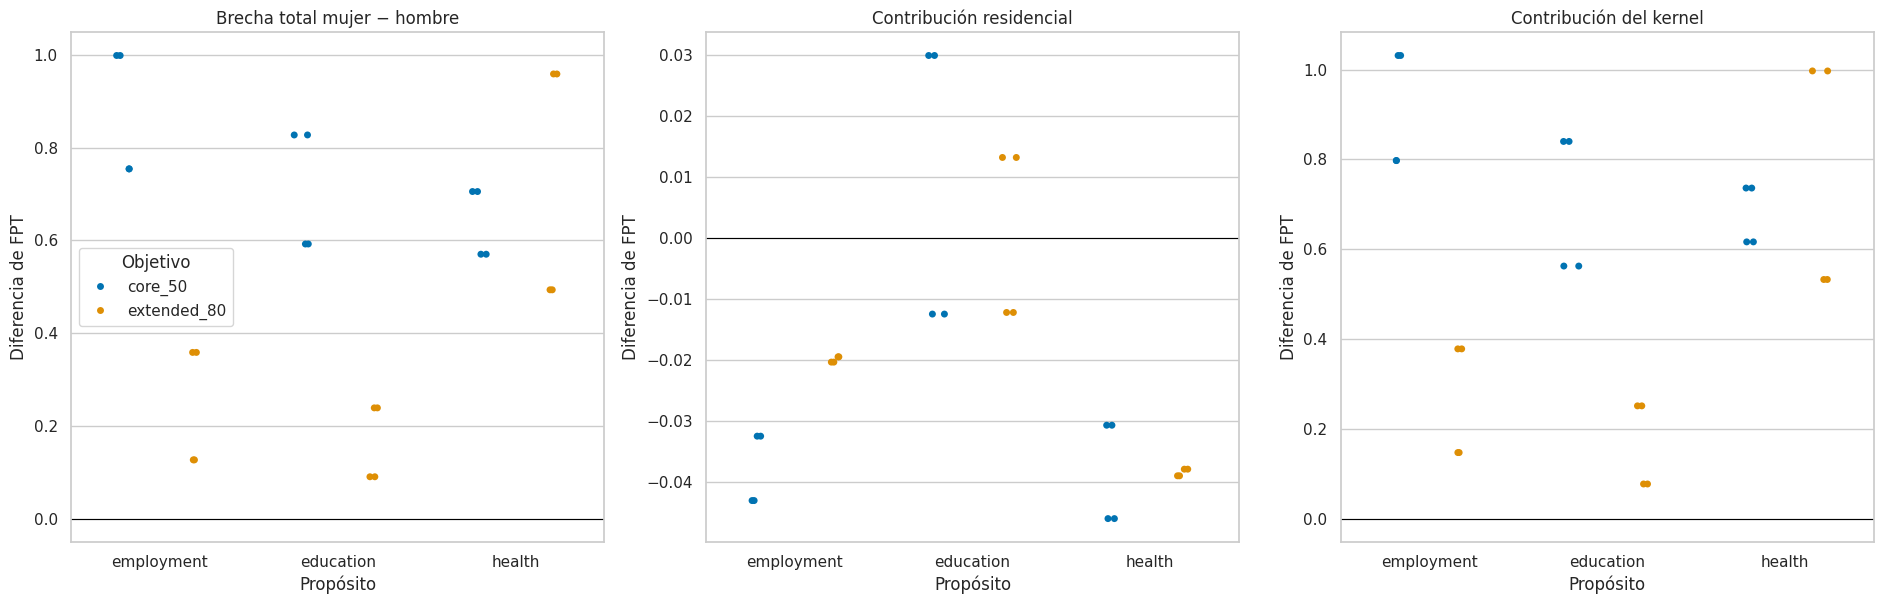

In [12]:
sns.set_theme(style="whitegrid", context="notebook")
plot_data = sex_robustness.copy()
plot_data["specification"] = (
    plot_data["reference_scheme"].map({
        "full_population": "Población completa",
        "valid_dimension": "Categorías válidas",
    }) + "\n" + plot_data["target_definition"] + " · "
    + plot_data["conditioning"].map({
        "outside_target": "condicional",
        "all_residences": "no condicional",
    })
)
fig, axes = plt.subplots(1, 3, figsize=(19, 6.2), sharey=False)
components = [
    ("female_minus_male_total", "Brecha total mujer − hombre"),
    ("residential_contribution", "Contribución residencial"),
    ("kernel_contribution", "Contribución del kernel"),
]
purpose_order = list(PURPOSES)
for axis, (column, title) in zip(axes, components):
    sns.stripplot(
        data=plot_data, x="purpose_group", y=column,
        hue="target_definition", dodge=True, jitter=0.10,
        order=purpose_order, palette="colorblind", ax=axis,
    )
    axis.axhline(0, color="black", linewidth=0.8)
    axis.set(title=title, xlabel="Propósito", ylabel="Diferencia de FPT")
    if axis is not axes[0]:
        axis.get_legend().remove()
axes[0].legend(title="Objetivo", loc="best")
fig.tight_layout()
fig.savefig(OUT / "robustness_sex_decomposition.png", dpi=180, bbox_inches="tight")
plt.show()


## 7. Compuerta 10

La compuerta exige reproducción de Gate 9, cobertura completa del factorial, cierre
algebraico, estimaciones finitas y bootstrap completo. La estabilidad sustantiva se
reporta, pero no se usa para descartar resultados nulos o contradictorios.


In [13]:
expected_point_rows = (
    len(REFERENCE_SCHEMES) * len(TARGET_DEFINITIONS) * len(CONDITIONING_MODES)
    * len(PURPOSES) * len(expected_groups)
)
expected_sex_rows = (
    len(REFERENCE_SCHEMES) * len(TARGET_DEFINITIONS)
    * len(CONDITIONING_MODES) * len(PURPOSES)
)
expected_bootstrap_rows = BOOTSTRAP_REPLICATES * expected_sex_rows
thresholds = {
    "maximum_gate9_replication_error": 1e-9,
    "maximum_decomposition_closure_error": 1e-10,
    "minimum_weighted_residential_support_share": 0.90,
}
numeric_point = [
    "reference_baseline", "group_observed", "residential_main", "kernel_main",
    "interaction", "shapley_residential", "shapley_kernel", "total_gap",
]
checks = {
    "gate9_dependency_valid": bool(gate9_status.get("gate_9_passed", False)),
    "gate9_primary_specification_reproduced": bool(
        max(point_replication_error, sex_replication_error)
        <= thresholds["maximum_gate9_replication_error"]
    ),
    "category_audit_complete": bool(len(category_coverage) == 4),
    "residential_support_valid": bool(
        support_audit.loc[0, "person_weight_residential_support_share"]
        >= thresholds["minimum_weighted_residential_support_share"]
    ),
    "factorial_grid_complete": bool(
        len(point) == expected_point_rows and len(sex_robustness) == expected_sex_rows
    ),
    "point_estimates_finite": bool(np.isfinite(point[numeric_point].to_numpy()).all()),
    "factorial_identity_valid": bool(
        point["closure_error"].abs().max()
        <= thresholds["maximum_decomposition_closure_error"]
    ),
    "sex_identity_valid": bool(
        sex_robustness["closure_error"].abs().max()
        <= thresholds["maximum_decomposition_closure_error"]
    ),
    "bootstrap_complete": bool(
        bootstrap["replicate"].nunique() == BOOTSTRAP_REPLICATES
        and len(bootstrap) == expected_bootstrap_rows
    ),
    "bootstrap_intervals_finite": bool(
        np.isfinite(intervals[["ci_lower", "ci_upper"]].to_numpy()).all()
    ),
}
checks["gate_10_passed"] = bool(all(checks.values()))

substantive_diagnostics = {
    "female_male_total_gap_positive_all_specifications": bool(
        sex_robustness["female_minus_male_total"].gt(0).all()
    ),
    "kernel_contribution_positive_all_specifications": bool(
        sex_robustness["kernel_contribution"].gt(0).all()
    ),
    "primary_residential_intervals_include_zero_all_purposes": bool(
        intervals[
            intervals["reference_scheme"].eq("full_population")
            & intervals["target_definition"].eq("core_50")
            & intervals["conditioning"].eq("outside_target")
            & intervals["effect"].eq("residential_contribution")
        ].apply(lambda row: row.ci_lower <= 0 <= row.ci_upper, axis=1).all()
    ),
}

report = {
    "generated_utc": datetime.now(timezone.utc).isoformat(),
    "source_sha256": str(source_manifest.loc[0, "sha256"]),
    "estimand": "robustness grid for residential-kernel FPT decomposition",
    "reference_schemes": list(REFERENCE_SCHEMES),
    "target_definitions": list(TARGET_DEFINITIONS),
    "conditioning_modes": list(CONDITIONING_MODES),
    "regularization_tau": float(PRIMARY_TAU),
    "bootstrap": {
        "method": "joint Poisson(1) household cluster bootstrap",
        "replicates": int(BOOTSTRAP_REPLICATES),
        "random_seed": int(RANDOM_SEED),
    },
    "thresholds": {key: float(value) for key, value in thresholds.items()},
    "category_coverage": json.loads(category_coverage.to_json(orient="records")),
    "stability": json.loads(stability.to_json(orient="records")),
    "substantive_diagnostics": substantive_diagnostics,
    "gate": checks,
}
(OUT / "gate_10.json").write_text(
    json.dumps(report, ensure_ascii=False, indent=2, allow_nan=False), encoding="utf-8"
)
pd.Series(checks, name="result").to_csv(OUT / "gate_10_checks.csv")
display(pd.Series(checks, name="result"))
display(pd.Series(substantive_diagnostics, name="result"))

persistent_out = DRIVE_BASE / "results/gate10"
persistent_out.mkdir(parents=True, exist_ok=True)
for artifact in OUT.iterdir():
    if artifact.is_file():
        shutil.copy2(artifact, persistent_out / artifact.name)

print("Compuerta 10:", "APROBADA" if checks["gate_10_passed"] else "NO APROBADA")
print("Copia persistente:", persistent_out)


,result
gate9_dependency_valid,True
gate9_primary_specification_reproduced,True
category_audit_complete,True
residential_support_valid,True
factorial_grid_complete,True
point_estimates_finite,True
factorial_identity_valid,True
sex_identity_valid,True
bootstrap_complete,True
bootstrap_intervals_finite,True


,result
female_male_total_gap_positive_all_specifications,True
kernel_contribution_positive_all_specifications,True
primary_residential_intervals_include_zero_all_purposes,True


Compuerta 10: APROBADA
Copia persistente: /content/drive/MyDrive/colombia-stochastic-access-data/bogota_em2023/results/gate10


## Decisión posterior a la Gate 10

- Si la dirección y el orden de magnitud por sexo son estables, la especificación de Gate 9
  permanece como principal y las alternativas se reportan como robustez.
- La referencia por categorías válidas será la principal para interpretar estratos si la
  cobertura de estrato incompleto altera materialmente la referencia poblacional.
- Ninguna asociación por estrato se interpretará causalmente.
- Tras aprobar esta compuerta, se aumentará el bootstrap de la especificación final a
  500–1000 réplicas y se prepararán tablas y figuras de manuscrito.
